# Data Analysis Framework

데이터 분석 툴 개발 테스트<br>
<br>

주요 기능
- 데이터 특성 분석<br>
    * 속성 : 크기, 길이, 타입, 중복, 결측치, 이상치, 분포, 패턴, 상관관계<br>
    * 교차 분석 : 임베딩 추출을 통한 이종 데이터 분석<br>
<br><br>
- 분석 시각화<br>
    * 시계열 데이터 : 시계열 그래프, 히스토그램 등<br>
    * 이미지 데이터 : 이미지 시각화, 임베딩 그래프 등<br>
    * 텍스트 데이터 : 텍스트 시각화, 워드클라우드 등<br>
    * 분석 리포트 : 속성, 데이터 드리프트, 교차 분석 결과 등<br>
<br><br>
- 데이터 드리프트 검출<br>
    * 데이터 드리프트 검출 알고리즘 적용<br>
    * 유입 데이터의 특성 변화에 따른 모델 성능 변화 예측, 검출<br>
<br><br>
- 솔루션 제공<br>
    * 유입된 데이터를 분류하여 학습에 적합한 데이터 선별, 가공<br>
    * 유입된 데이터 특성 파악을 통한 데이터 가공 방법, 적합한 기계학습 모델 및 태스크를 추천<br>
    * 드리프트 관제 및 탐지

>해당 노트북에서는..<br>
>* 기본적인 데이터 제어 및 조작 테스트
>* framework 기능 테스트 (fiftyone, dash)
>* 시각화 기능 고도화 테스트 (fiftyone embedding visualization)


## Input Data 처리

파일 분류, 기본 속성 추출

In [1]:
import torch
import clip

import pandas as pd
import os
import math
from PIL import Image

In [2]:
def convert_size(size_bytes):

    if size_bytes == 0:
        return "0B"
    size_name = ("B", "KB", "MB", "GB", "TB", "PB", "EB", "ZB", "YB")
    i = int(math.floor(math.log(size_bytes, 1024)))
    p = math.pow(1024, i)
    s = round(size_bytes / p, 2)

    return "%s%s" % (s, size_name[i])


def list_files_recursive(dir_path, extension_dict=None):

    if extension_dict is None:
        extension_dict = {}
    
    file_list = sorted(os.listdir(dir_path))  # Sort the list of files and directories
    
    if dir_path not in extension_dict:
        extension_dict[dir_path] = {}
    
    for item in file_list:
        full_path = os.path.join(dir_path, item)

        if os.path.isdir(full_path):
            list_files_recursive(full_path, extension_dict)  # Recursive call
        else:
            ext = os.path.splitext(item)[1]  # Get file extension
            if ext not in extension_dict[dir_path]:
                extension_dict[dir_path][ext] = []
            extension_dict[dir_path][ext].append(full_path)  # Store full path for clarity
    
    return extension_dict

def print_files_sorted(extension_dict):

    for dir_path, extensions in sorted(extension_dict.items()):
        print()
        print(f"Directory: {dir_path}")

        for ext, files in sorted(extensions.items(), reverse=True):  # Sort extensions in descending order
            print(f"  Files with extension {ext}:")
            
            for file in sorted(files, reverse=True):  # Sort files in descending order
                print(f"    {os.path.basename(file)} {convert_size(os.path.getsize(file))}")

def count_files_by_extension(extension_dict):

    total_files_by_ext = {}
    total_size_by_ext = {}
    total_size = 0
    
    for extensions in extension_dict.values():
        for ext, files in extensions.items():
            
            if ext not in total_files_by_ext:
                total_files_by_ext[ext] = len(files)
                file_size_sum = sum(os.path.getsize(file) for file in files)
                total_size_by_ext[ext] = file_size_sum
                total_size += file_size_sum
            else:
                total_files_by_ext[ext] += len(files)
                file_size_sum = sum(os.path.getsize(file) for file in files)
                total_size_by_ext[ext] += file_size_sum
                total_size += file_size_sum

    print("Total files count : {}".format(sum(total_files_by_ext.values())))
    print("Total size : {}".format(convert_size(total_size)))
    print()
    
    for ext, count in sorted(total_files_by_ext.items()):
        size = convert_size(total_size_by_ext[ext])
        print(f"{ext}: {count} files, {size}")

In [3]:
dir_path = './test1'

extension_dict = list_files_recursive(dir_path)

In [4]:
print_files_sorted(extension_dict)


Directory: ./test1
  Files with extension .txt:
    test.txt 905.0B
  Files with extension .py:
    dash_testApp.py 4.73KB
  Files with extension .mp4:
    test.mp4 0B
  Files with extension .mp3:
    test.mp3 0B
  Files with extension .log:
    test.log 0B
  Files with extension .key:
    test.key 0B
  Files with extension .csv:
    test_txt.csv 910.0B
    test_ref.csv 22.93KB
    test_cur.csv 1.73KB
  Files with extension .bak:
    test.bak 0B

Directory: ./test1/imgs
  Files with extension .png:
    car28.png 251.76KB
    car27.png 640.27KB
    car26.png 220.04KB
    car25.png 487.8KB
    car24.png 892.48KB
    car23.png 528.89KB
    car22.png 177.38KB
  Files with extension .jpg:
    tmt9.jpg 1.38MB
    tmt8.jpg 1.34MB
    tmt7.jpg 1.1MB
    tmt6.jpg 1.38MB
    tmt5.jpg 1.38MB
    tmt4.jpg 1.43MB
    tmt3.jpg 1.22MB
    tmt12.jpg 1.56MB
    tmt11.jpg 1.43MB
    tmt10.jpg 1.31MB
    tank5.jpg 41.46KB
    tank4.jpg 44.0KB
    tank3.jpg 31.74KB
    tank2.jpg 31.58KB
    tank1.jpg 40.

In [5]:
count_files_by_extension(extension_dict)

Total files count : 109
Total size : 59.85MB

.bak: 1 files, 0B
.csv: 3 files, 25.55KB
.jpeg: 2 files, 676.71KB
.jpg: 57 files, 55.87MB
.key: 1 files, 0B
.log: 2 files, 0B
.mp3: 1 files, 0B
.mp4: 1 files, 0B
.png: 37 files, 3.29MB
.py: 2 files, 4.77KB
.txt: 2 files, 949.0B


In [6]:
im = Image.open('./test1/imgs/car1.jpg')
width, height = im.size
print(width, height)

268 188


In [7]:
f = open('./test1/test.txt', 'r')
txt_file = f.read().splitlines()

In [8]:
df = pd.DataFrame({"sent" : txt_file})

df

,sent
0,this is dummy text file for da framework
1,Hello world
2,98745632 is random numbers
3,this tomato is unripened
4,there is a car accident on the road
5,this car is very expensive vehicle
6,there are many cars today
7,i prefer suv rather than sedan
8,he doesn't like audi cars
9,she looks so young


In [9]:
df = pd.read_csv('./test1/test_ref.csv')
df.head()

,date,Open,High,Low,Close,Volume,Dividends,stock_splits
0,2020-01-02,163.919998,167.070007,163.580002,166.990005,5189300,0,0.0
1,2020-01-03,165.059998,166.770004,165.000000,166.169998,3205400,0,0.0
2,2020-01-06,165.000000,173.669998,164.449997,173.449997,8836200,0,0.0
3,2020-01-07,173.229996,176.869995,172.089996,176.000000,8272700,0,0.0
4,2020-01-08,175.229996,178.850006,174.750000,177.330002,7225100,0,0.0


In [10]:
len(df)

253

In [11]:
for col in df.columns:
    print(f" {col} column dtype : {df[col].dtype}")
    print(type(df[col][0]))
    print()

 date column dtype : object
<class 'str'>

 Open column dtype : float64
<class 'numpy.float64'>

 High column dtype : float64
<class 'numpy.float64'>

 Low column dtype : float64
<class 'numpy.float64'>

 Close column dtype : float64
<class 'numpy.float64'>

 Volume column dtype : int64
<class 'numpy.int64'>

 Dividends column dtype : int64
<class 'numpy.int64'>

 stock_splits column dtype : float64
<class 'numpy.float64'>



In [12]:
df['Open'][0]

163.9199981689453

## Embedding

데이터 임베딩 추출 및 조작, 시각화

In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [14]:
f = open('./test1/test.txt', 'r')
txt_file = f.read().splitlines()
df = pd.DataFrame({"sent" : txt_file})

image = preprocess(Image.open("./test1/imgs/car1.jpg")).unsqueeze(0).to(device)
text = clip.tokenize(df['sent'][0]).to(device)

In [15]:
image

tensor([[[[ 0.3537,  0.3537,  0.3245,  ...,  0.4997,  0.4997,  0.5143],
          [ 0.3537,  0.3537,  0.3391,  ...,  0.4997,  0.4997,  0.5143],
          [ 0.3683,  0.3537,  0.3391,  ...,  0.4997,  0.4997,  0.5143],
          ...,
          [ 0.4705,  0.4267,  0.3683,  ..., -0.4784, -0.4492, -0.1864],
          [ 0.4121,  0.3829,  0.3099,  ..., -0.5368, -0.5952, -0.3762],
          [ 0.3975,  0.3829,  0.2807,  ..., -0.3908, -0.4930, -0.4638]],

         [[ 0.5141,  0.5141,  0.4991,  ...,  0.4691,  0.4691,  0.4540],
          [ 0.5141,  0.5141,  0.5141,  ...,  0.4691,  0.4691,  0.4540],
          [ 0.5291,  0.5141,  0.5141,  ...,  0.4691,  0.4691,  0.4540],
          ...,
          [ 0.3340,  0.2890,  0.2289,  ..., -0.6565, -0.6265, -0.4314],
          [ 0.2740,  0.2439,  0.1689,  ..., -0.7016, -0.7616, -0.6415],
          [ 0.2589,  0.2439,  0.1389,  ..., -0.5515, -0.6565, -0.7466]],

         [[ 0.7097,  0.7097,  0.6955,  ...,  0.2120,  0.2120,  0.2120],
          [ 0.7097,  0.7097,  

In [16]:
text

tensor([[49406,   589,   533, 34246,  4160,  4512,   556,  1140, 13195, 49407,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0]], dtype=torch.int32)

In [17]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import numpy as np

# 텍스트와 이미지 임베딩 얻기
with torch.no_grad():
    text_features = model.encode_text(text)
    image_features = model.encode_image(image)

In [18]:
# def reduce_dimension(embedding, n_components=2):
#     tsne = TSNE(n_components=n_components, random_state=42)
#     return tsne.fit_transform(embedding.reshape(1, -1))[0]

# def reduce_dimension(embedding, n_components=2):
#     pca = PCA(n_components=n_components)
#     return pca.fit_transform(embedding.reshape(1, -1))[0]

def reduce_dimension(embedding, n_components=2):
    return np.max(embedding.reshape(-1, embedding.shape[0] // n_components), axis=1)


In [19]:
# CPU로 이동 및 numpy 배열로 변환
text_features = text_features.cpu().numpy().flatten()
image_features = image_features.cpu().numpy().flatten()

# 2차원으로 축소
text_2d = reduce_dimension(text_features)
image_2d = reduce_dimension(image_features)

print("Text embedding 2D:", text_2d)
print("Image embedding 2D:", image_2d)

Text embedding 2D: [6.889923  6.8926234]
Image embedding 2D: [1.5767788 1.0927585]


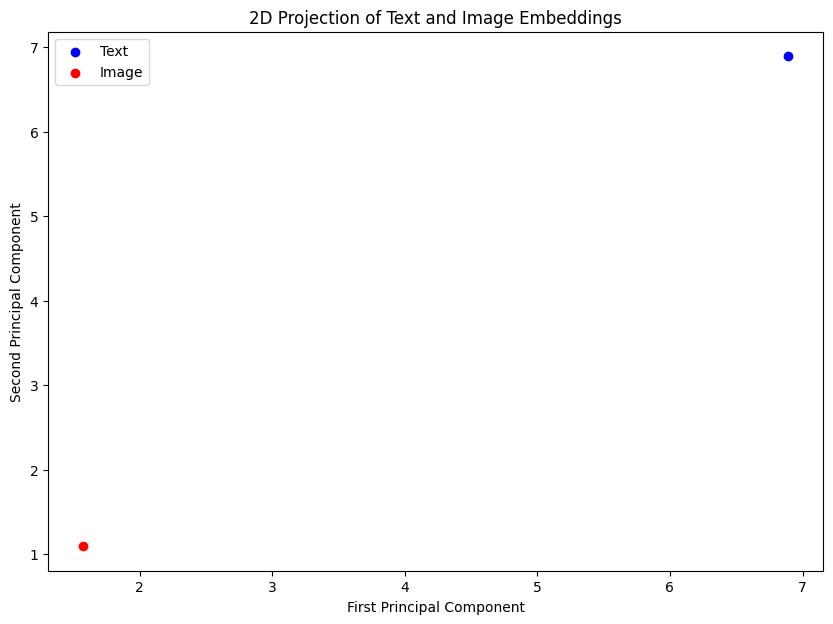

In [20]:
# 시각화 (선택사항)
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(text_2d[0], text_2d[1], c='blue', label='Text')
plt.scatter(image_2d[0], image_2d[1], c='red', label='Image')
plt.legend()
plt.title('2D Projection of Text and Image Embeddings')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

In [21]:
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import pandas as pd
import base64
from PIL import Image
import io

In [22]:
fig = px.imshow(Image.open('./test1/imgs/car1.jpg'))
fig.show()

## Visualization

### ```Dash``` 시각화 앱 구동 테스트

In [23]:
import dash
from dash import dcc, html
from dash.dependencies import Input, Output

# 데이터프레임 생성
df = pd.DataFrame({
    'x': [text_2d[0], image_2d[0]],
    'y': [text_2d[1], image_2d[1]],
    'type': ['Text', 'Image'],
    'content': ['this is dummy text file for da framework', './test/imgs/car1.jpg']
})

app = dash.Dash(__name__)

app.layout = html.Div([
    html.H1("Embedding Visualization", style={'textAlign': 'center'}),
    html.Div([
        html.Div([
            dcc.Graph(id='scatter-plot', style={'height': '80vh'})
        ], style={'width': '60%', 'display': 'inline-block'}),
        html.Div([
            html.Div(id='content-display', style={'height': '80vh', 'overflowY': 'auto'})
        ], style={'width': '40%', 'display': 'inline-block', 'verticalAlign': 'top', 'padding': '20px'})
    ], style={'display': 'flex', 'flexDirection': 'row'})
], style={'fontFamily': 'Arial, sans-serif'})

@app.callback(
    Output('content-display', 'children'),
    [Input('scatter-plot', 'clickData')]
)
def update_content(clickData):
    if clickData is None:

        return html.P("Click a point to see the content")
    
    point_index = clickData['points'][0]['pointIndex']
    content_type = df.iloc[point_index]['type']
    content = df.iloc[point_index]['content']
    
    if content_type == 'Text':

        return html.Div([
            html.H3("Text Content"),
            html.P(content)
        ])
    
    elif content_type == 'Image':
        try:
            img = Image.open(content)
            buffered = io.BytesIO()
            img.save(buffered, format="PNG")
            img_str = base64.b64encode(buffered.getvalue()).decode()

            return html.Div([
                html.H3("Image Content"),
                html.Img(src=f'data:image/png;base64,{img_str}', style={'width': '100%', 'height': 'auto'})
            ])
        
        except Exception as e:
            
            return html.P(f"Error displaying image: {e}")
    
    return html.P("Click a point to see the content")


@app.callback(
    Output('scatter-plot', 'figure'),
    [Input('scatter-plot', 'relayoutData')]
)
def update_scatter_plot(relayoutData):
    fig = go.Figure(data=[go.Scatter(
        x=df['x'],
        y=df['y'],
        mode='markers',
        marker=dict(size=10, color=['blue' if t == 'Text' else 'red' for t in df['type']]),
        text=df['type'],
        hoverinfo='text'
    )])
    
    fig.update_layout(
        title='Embedding Scatter Plot',
        xaxis_title='Dimension 1',
        yaxis_title='Dimension 2',
        hovermode='closest'
    )
    
    return fig

if __name__ == '__main__':
    app.run_server(debug=True, port=8059)

### ```FiftyOne``` 구동 테스트

In [24]:
import fiftyone as fo
import fiftyone.brain as fob

In [25]:
img_path = [
    './test1/imgs/car1.jpg',
]

img_dir_path = './test1/imgs/'

## 파일 개별 경로로 호출
# dataset = fo.Dataset.from_images(img_path)

## 파일 디렉토리로 호출
dataset = fo.Dataset.from_images_dir(img_dir_path)

## 파일 패턴으로 호출
# dataset = fo.Dataset.from_images_patt("./test/*.jpg")

session = fo.launch_app(dataset, port=8161)

 100% |███████████████████| 66/66 [16.8ms elapsed, 0s remaining, 3.9K samples/s]      


In [26]:
## CVAT : arm 기반 맥 OS 환경에서 실행 불가

# # A unique identifer for this run
# anno_key = "detections_run"

# # Upload the samples and launch CVAT
# anno_results = dataset.annotate(
#     anno_key,
#     label_field="detections",
#     # backend="labelbox",
#     label_type="instances",
#     classes=["person", "vehicle", "animal"],
#     launch_editor=True,
# )

#### 임베딩 그래프 구현


In [27]:
import cv2

# 데이터셋 생성
img_dir_path = './test1/imgs/'
dataset = fo.Dataset.from_images_dir(img_dir_path)

# CLIP 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 이미지 임베딩 추출
embeddings = []
for sample in dataset:
    image = preprocess(Image.open(sample.filepath)).unsqueeze(0).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image)
    embeddings.append(image_features.cpu().numpy().flatten())

embeddings = np.array(embeddings)

# 임베딩을 데이터셋에 추가
for sample, embedding in zip(dataset, embeddings):
    sample['clip_embedding'] = embedding.tolist()
    sample.save()

print(dataset.first())

 100% |███████████████████| 66/66 [11.1ms elapsed, 0s remaining, 6.0K samples/s]      
<Sample: {
    'id': '6712160020b692337f878dbf',
    'media_type': 'image',
    'filepath': '/Users/bhc/Desktop/dev/datadrift/da_framework/test1/imgs/car1.jpg',
    'tags': [],
    'metadata': None,
    'created_at': datetime.datetime(2024, 10, 18, 8, 2, 8, 111000),
    'last_modified_at': datetime.datetime(2024, 10, 18, 8, 2, 15, 142000),
    'clip_embedding': [
        0.48231741786003113,
        0.340238094329834,
        0.0021629605907946825,
        -0.4847186803817749,
        -0.04673333093523979,
        0.6916724443435669,
        -0.11306308954954147,
        0.15722405910491943,
        0.13291221857070923,
        0.15889522433280945,
        -0.07403113692998886,
        0.07333370298147202,
        0.22029800713062286,
        -0.08178887516260147,
        0.01042912621051073,
        -0.03290307894349098,
        1.0983905792236328,
        -0.4259849190711975,
        -0.36014190316

In [28]:
# 임베딩 시각화
results = fob.compute_visualization(
    dataset,
    embeddings=embeddings,
    pathes_field="clip_embeddings",
    brain_key="clip_embeddings",
    num_dims=3,
    plot_points=True,
    verbose=True,
)

# FiftyOne 앱 실행
session = fo.launch_app(dataset, port=8158)

Generating visualization...


/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning:

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html



UMAP(n_components=3, verbose=True)
Fri Oct 18 17:02:17 2024 Construct fuzzy simplicial set
Fri Oct 18 17:02:17 2024 Finding Nearest Neighbors


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fri Oct 18 17:02:18 2024 Finished Nearest Neighbor Search
Fri Oct 18 17:02:19 2024 Construct embedding


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Oct 18 17:02:20 2024 Finished embedding


#### 텍스트 데이터 시각화 테스트

FiftyOne 은 이미지 외의 데이터 형식에 대한 처리를 지원하지 않음
나머지 데이터에 대한 처리는 Dash를 활용하여 구현

In [29]:
# 텍스트 임베딩 생성
def get_embeddings(texts):

    with torch.no_grad():
        text_inputs = clip.tokenize(texts).to(device)
        text_features = model.encode_text(text_inputs)

    return text_features.cpu().numpy()

def reduce_dimension(embedding, n_components=2):

    return np.max(embedding.reshape(-1, embedding.shape[0] // n_components), axis=1)

In [30]:
# CLIP 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model, _ = clip.load("ViT-B/32", device=device)

f = open('./test1/test.txt', 'r')
txt_file = f.read().splitlines()
df = pd.DataFrame({"sent" : txt_file})
text_col = 'sent'

df

,sent
0,this is dummy text file for da framework
1,Hello world
2,98745632 is random numbers
3,this tomato is unripened
4,there is a car accident on the road
5,this car is very expensive vehicle
6,there are many cars today
7,i prefer suv rather than sedan
8,he doesn't like audi cars
9,she looks so young


In [31]:
embeddings = get_embeddings(df['sent'].tolist())

embeddings

array([[-0.20830321,  0.10155779, -0.32491094, ...,  0.16787516,
        -0.31168392,  0.41915458],
       [ 0.10204648,  0.12730782, -0.16999172, ..., -0.24586082,
        -0.21527994,  0.24384835],
       [ 0.3202839 ,  0.17610283,  0.16704153, ...,  0.33249447,
        -0.53965527, -0.11645961],
       ...,
       [ 0.16224779, -0.09016364, -0.24474122, ...,  0.10682739,
        -0.06970664, -0.16883034],
       [-0.13146369,  0.10682642,  0.07890408, ...,  0.14632897,
        -0.0920282 , -0.03365453],
       [-0.1465528 , -0.09524172, -0.09622364, ...,  0.70524734,
        -0.25661483, -0.21011181]], dtype=float32)

In [32]:
len(embeddings)

30

In [33]:
# PCA를 사용하여 2D로 차원 축소
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

embeddings_2d

array([[ 1.0905666 , -0.42117888],
       [ 2.0107954 ,  0.59746563],
       [ 1.0898497 , -0.20655069],
       [-5.6498337 ,  0.49993128],
       [ 0.85582507, -2.5013096 ],
       [ 1.5352681 , -2.7975821 ],
       [ 1.398685  , -2.7917068 ],
       [ 1.4953622 , -2.3393497 ],
       [ 0.77600724, -2.3318696 ],
       [ 2.1083064 ,  2.5563817 ],
       [ 0.47598082, -0.20310695],
       [ 1.5975497 ,  0.7274066 ],
       [ 1.8932787 ,  1.3967113 ],
       [ 1.3643211 ,  1.7568724 ],
       [ 2.244076  ,  2.3163106 ],
       [ 0.6050229 , -0.08153327],
       [ 1.6075866 , -1.8498119 ],
       [ 1.7440532 ,  1.5645095 ],
       [ 2.2936747 ,  2.2707942 ],
       [ 1.9714739 ,  0.5104743 ],
       [ 0.4284997 , -0.28459665],
       [-0.2029811 , -0.46994135],
       [ 1.2560201 ,  0.6013254 ],
       [-3.1314967 ,  0.39557815],
       [-4.665088  ,  0.39072275],
       [-2.5429702 ,  0.19059487],
       [-2.489694  ,  0.1039901 ],
       [-2.1298006 ,  0.09670019],
       [-3.3964365 ,

In [34]:
# 2D 임베딩을 DataFrame에 추가
df['x'] = embeddings_2d[:, 0]
df['y'] = embeddings_2d[:, 1]

df

,sent,x,y
0,this is dummy text file for da framework,1.090567,-0.421179
1,Hello world,2.010795,0.597466
2,98745632 is random numbers,1.089850,-0.206551
3,this tomato is unripened,-5.649834,0.499931
4,there is a car accident on the road,0.855825,-2.501310
5,this car is very expensive vehicle,1.535268,-2.797582
6,there are many cars today,1.398685,-2.791707
7,i prefer suv rather than sedan,1.495362,-2.339350
8,he doesn't like audi cars,0.776007,-2.331870
9,she looks so young,2.108306,2.556382


In [35]:
# Dash 앱 초기화
app = dash.Dash(__name__)

# 앱 레이아웃 정의
app.layout = html.Div([
    html.H1("문장 임베딩 시각화", style={'textAlign': 'center'}),
    html.Div([
        html.Div([
            dcc.Graph(id='scatter-plot', style={'height': '80vh'})
        ], style={'width': '60%', 'display': 'inline-block', 'vertical-align': 'top'}),
        html.Div([
            html.H3("선택된 문장"),
            html.Div(id='text-display', style={'whiteSpace': 'pre-wrap', 'word-wrap': 'break-word'})
        ], style={'width': '35%', 'display': 'inline-block', 'vertical-align': 'top', 'padding': '20px'})
    ])
], style={'padding': '20px'})

# 콜백 함수 정의
@app.callback(
    Output('text-display', 'children'),
    Input('scatter-plot', 'clickData'))
def display_text(clickData):
    if clickData is None:
        return "포인트를 클릭하여 문장을 표시합니다."
    point_index = clickData['points'][0]['customdata'][0]
    text = df.iloc[point_index]['sent']
    return f"\n{text}"

# 산점도 그래프 생성
@app.callback(
    Output('scatter-plot', 'figure'),
    Input('scatter-plot', 'relayoutData'))
def update_graph(relayoutData):
    fig = px.scatter(df, x='x', y='y', hover_data=['sent'],
                     custom_data=[df.index])
    fig.update_traces(marker=dict(size=10),
                      selector=dict(mode='markers'))
    fig.update_layout(title='문장 임베딩 2D 시각화',
                      xaxis_title='첫 번째 주성분',
                      yaxis_title='두 번째 주성분')
    return fig

# 앱 실행
if __name__ == '__main__':
    app.run_server(debug=True, port=8058)

### ```FiftyOne``` 테스트 고도화

* 데이터 태그 삽입
* 데이터 메타데이터 추가
* 데이터 병합
* 텍스트 데이터 이미지 생성 및 시각화
* 이미지 및 텍스트 데이터 동시 로드

#### 데이터 제어 테스트

데이터 태그, 메타데이터 수정 및 데이터셋 병합 기능 테스트 등

In [36]:
import fiftyone as fo
import fiftyone.brain as fob
import cv2

dir_path_1 = './test1/'
dataset_1 = fo.Dataset.from_images_dir(dir_path_1)
dir_path_2 = './test2/'
dataset_2 = fo.Dataset.from_images_dir(dir_path_2)

for sample in dataset_1:
    sample.tags.append("dataset_1")
    sample.save()

for sample in dataset_2:
    sample.tags.append("dataset_2")
    sample.save()

print(dataset_1.first())
print(dataset_2.first())

 100% |███████████████████| 96/96 [13.2ms elapsed, 0s remaining, 7.3K samples/s]      
 100% |█████████████████| 107/107 [13.2ms elapsed, 0s remaining, 8.1K samples/s]      
<Sample: {
    'id': '6712161120b692337f878e09',
    'media_type': 'image',
    'filepath': '/Users/bhc/Desktop/dev/datadrift/da_framework/test1/imgs/car1.jpg',
    'tags': ['dataset_1'],
    'metadata': None,
    'created_at': datetime.datetime(2024, 10, 18, 8, 2, 25, 992000),
    'last_modified_at': datetime.datetime(2024, 10, 18, 8, 2, 26, 68000),
}>
<Sample: {
    'id': '6712161220b692337f878e6a',
    'media_type': 'image',
    'filepath': '/Users/bhc/Desktop/dev/datadrift/da_framework/test2/1.jpg',
    'tags': ['dataset_2'],
    'metadata': None,
    'created_at': datetime.datetime(2024, 10, 18, 8, 2, 26, 58000),
    'last_modified_at': datetime.datetime(2024, 10, 18, 8, 2, 26, 94000),
}>


In [37]:
print(len(dataset_1))
print(len(dataset_2))

96
107


In [38]:
## Clean up FiftyOne Datasets

# for d in fo.list_datasets():
#     dataset = fo.load_dataset(d)
#     dataset.delete()

# fo.list_datasets()

In [39]:
merged_dataset = fo.Dataset("merged_dataset")

merged_dataset.add_samples(dataset_1)
merged_dataset.add_samples(dataset_2)

print(len(merged_dataset))

 100% |███████████████████| 96/96 [19.8ms elapsed, 0s remaining, 4.9K samples/s]      
 100% |█████████████████| 107/107 [16.1ms elapsed, 0s remaining, 6.7K samples/s]      
203


In [40]:
session = fo.launch_app(merged_dataset, port=8157)

#### 텍스트 이미지 생성 기능 구현

텍스트 데이터에 대한 이미지 데이터를 생성하여 fiftyone을 통해 데이터를 로드할 수 있게 구현

In [41]:
import pandas as pd

f = open('./test1/test.txt', 'r')
txt_file = f.read().splitlines()
df = pd.DataFrame({"sent" : txt_file})

In [42]:
len(df)

30

In [43]:
df.to_csv('./test1/test_txt.csv', index=False)

In [44]:
df = pd.read_csv('./test1/test_txt.csv')

df

,sent
0,this is dummy text file for da framework
1,Hello world
2,98745632 is random numbers
3,this tomato is unripened
4,there is a car accident on the road
5,this car is very expensive vehicle
6,there are many cars today
7,i prefer suv rather than sedan
8,he doesn't like audi cars
9,she looks so young


이미지 생성 함수

In [45]:
from PIL import Image, ImageDraw, ImageFont
import textwrap

def generate_text_image(text, font_path="Geneva.ttf", max_width=600, font_size=30, line_spacing=5):

    back_color = (255, 255, 255)
    text_color = (0, 0, 0)

    font = ImageFont.truetype(font_path, font_size)
    lines = textwrap.wrap(text, width=max_width//font_size)

    # 이미지 크기 계산
    line_height = font.getbbox('hg')[3] - font.getbbox('hg')[1] + line_spacing
    img_height = line_height * len(lines) + 40  # 위아래 여백 20px씩

    image = Image.new("RGB", (max_width, img_height), back_color)
    draw = ImageDraw.Draw(image)

    # 텍스트 그리기
    y_text = 20
    for line in lines:
        bbox = font.getbbox(line)
        line_width = bbox[2] - bbox[0]
        line_height = bbox[3] - bbox[1]
        draw.text(((max_width - line_width) / 2, y_text), line, font=font, fill=text_color)
        y_text += line_height + line_spacing

    return image

동작 테스트

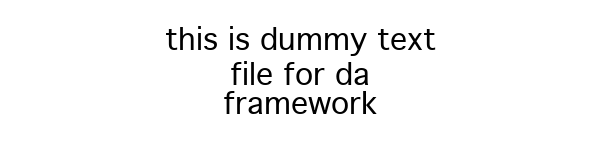

In [46]:
image = generate_text_image(df['sent'][0])

image

텍스트 데이터 전처리구간 추가 및 테스트

In [47]:
df = pd.read_csv('./test2/facebook_post.csv')

print(df['post_text'][0])

Start on the right foot for your first impression - Square Edge Heel Sandals 😎
 
 Shop via link in bio ✨
 
 #DMKSHOES #journeywithcourage


In [48]:
from emoji import core
import re

text = df['post_text'][0]
text = re.sub(r"[^\uAC00-\uD7A30-9a-zA-Z\s]", "", text)
text = core.replace_emoji(text, replace="")
df.loc[0, 'post_text'] = text

print(df['post_text'][0])

Start on the right foot for your first impression  Square Edge Heel Sandals 
 
 Shop via link in bio 
 
 DMKSHOES journeywithcourage


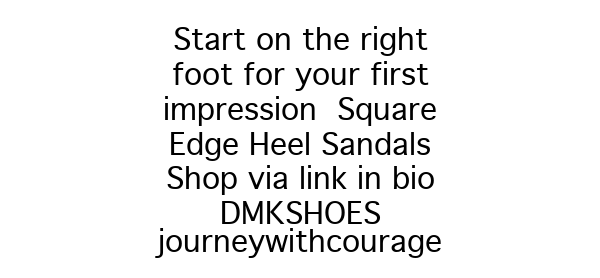

In [49]:
image = generate_text_image(text)

image

## DA Framework demo app 구축

* 이종 데이터셋 쌍의 기본정보 교차 분석 리포트 생성
* 이종 데이터셋 쌍의 임베딩 시각화
* 이미지 및 텍스트 데이터 동시 처리 가능

### 텍스트 데이터 전처리

df2 데이터 분할 -> 50개 데이터 추출<br>
이모지, 특수문자 제거

In [50]:
import pandas as pd

df1 = pd.read_csv('./test1/test_txt.csv')
df2 = pd.read_csv('./test2/facebook_post.csv')

len(df1)

30

In [51]:
df1.head()

,sent
0,this is dummy text file for da framework
1,Hello world
2,98745632 is random numbers
3,this tomato is unripened
4,there is a car accident on the road


In [52]:
df2 = df2.loc[:49, ['post_text']]
df2.rename(columns={'post_text' : 'sent'}, inplace=True)

len(df2)

50

In [53]:
df2['sent'][0]

'Start on the right foot for your first impression - Square Edge Heel Sandals 😎\n \n Shop via link in bio ✨\n \n #DMKSHOES #journeywithcourage'

In [54]:
import re
from emoji import replace_emoji
from PIL import Image, ImageDraw, ImageFont
import textwrap


def clean_text(text):
    # 이모티콘 제거
    text = replace_emoji(text, replace='')
    # 특수문자 제거 (알파벳, 숫자, 한글, 공백만 남김)
    text = re.sub(r'[^a-zA-Z0-9가-힣\s]', '', text)
    # 연속된 공백을 하나의 공백으로 대체
    text = re.sub(r'\s+', ' ', text).strip()
    # 소문자로 통일
    text = text.lower()
    # 문자열 길이 제한 (단어 수)
    # if len(text.split(" ")) > 75:
    #     text = (' ').join(text.split(" ")[:75])

    return text

def generate_text_image(text, font_path="Geneva.ttf", max_width=600, font_size=30, line_spacing=5):

    back_color = (255, 255, 255)
    text_color = (0, 0, 0)

    font = ImageFont.truetype(font_path, font_size)
    lines = textwrap.wrap(text, width=max_width//font_size)

    # 이미지 크기 계산
    line_height = font.getbbox('hg')[3] - font.getbbox('hg')[1] + line_spacing
    img_height = line_height * len(lines) + 40  # 위아래 여백 20px씩

    image = Image.new("RGB", (max_width, img_height), back_color)
    draw = ImageDraw.Draw(image)

    # 텍스트 그리기
    y_text = 20
    for line in lines:
        bbox = font.getbbox(line)
        line_width = bbox[2] - bbox[0]
        line_height = bbox[3] - bbox[1]
        draw.text(((max_width - line_width) / 2, y_text), line, font=font, fill=text_color)
        y_text += line_height + line_spacing

    return image

In [55]:
df1['sent'] = df1['sent'].apply(clean_text)
df2['sent'] = df2['sent'].apply(clean_text)

In [56]:
df2['sent'].tolist()

['start on the right foot for your first impression square edge heel sandals shop via link in bio dmkshoes journeywithcourage',
 'getting that crop top wide trousers combo right in square edge heel sandals shop via link in bio dmkshoes journeywithcourage',
 'sweet dreams are made of these bubble dream heel sandals shop via link in bio dmkshoes journeywithcourage',
 'annavanticalopez disneys ceo bob iger is my biggest inspiration reading his book was a turning point for me especially this quote no matter who we become or what we accomplish we still feel that were essentially the kid we were at some simpler time long ago the moment you look yourself in the mirror and see a title emblazoned on your forehead youve lost your way youre the same person youve always been if theres any advice i could give it will be like the essence of his message to not lose your selfidentity because your selfidentity is what makes you who you are and nobody can change that about you i always held my identity 

### 데이터셋 구축

* 텍스트 임베딩 생성
* 텍스트 이미지 생성
* 이미지 임베딩 생성
* 데이터셋 머지

In [57]:
import fiftyone as fo
import fiftyone.brain as fob
import cv2
import os


# FiftyOne Datasets 초기화

for d in fo.list_datasets():
    dataset = fo.load_dataset(d)
    dataset.delete()

fo.list_datasets()

[]

In [58]:
import torch
import clip

# 임베딩 생성 함수 : 이미지, 텍스트 구분
def get_embeddings(sample):

    if sample.tags[1] == "image":
        with torch.no_grad():
            inputs = preprocess(Image.open(sample.filepath)).unsqueeze(0).to(device)
            features = model.encode_image(inputs)

    elif sample.tags[1] == "text":
        with torch.no_grad():
            inputs = clip.tokenize(sample.original_text, context_length=77, truncate=True).to(device)
            features = model.encode_text(inputs)

    return features.cpu().numpy().flatten()

In [59]:
import shutil

def delete(path):
    if os.path.isfile(path):
        os.remove(path)
    elif os.path.isdir(path):
        shutil.rmtree(path)
    else:
        raise ValueError("해당 경로를 확인해주세요")

In [60]:
txtimg1_dir = './test1/txt_img'
txtimg2_dir = './test2/txt_img'

delete(txtimg1_dir)
delete(txtimg2_dir)

In [61]:
dir_path_1 = './test1/'
dataset_1 = fo.Dataset.from_images_dir(dir_path_1)
dir_path_2 = './test2/'
dataset_2 = fo.Dataset.from_images_dir(dir_path_2)

for sample in dataset_1:
    sample.tags.append("dataset_1")
    sample.tags.append("image")
    sample.save()

for sample in dataset_2:
    sample.tags.append("dataset_2")
    sample.tags.append("image")
    sample.save()

 100% |███████████████████| 66/66 [11.9ms elapsed, 0s remaining, 5.5K samples/s]      
 100% |███████████████████| 57/57 [13.4ms elapsed, 0s remaining, 4.3K samples/s]      


In [62]:
os.makedirs(txtimg1_dir, exist_ok=True)
os.makedirs(txtimg2_dir, exist_ok=True)

for i, txt in enumerate(df1['sent']):
    # 텍스트 이미지 생성
    image = generate_text_image(txt)
    image.save(f'./test1/txt_img/txt_{i}.png')
    # 이미지 샘플 생성
    sample = fo.Sample(filepath=f'./test1/txt_img/txt_{i}.png')
    sample.tags.append("dataset_1")
    sample.tags.append("text")
    sample["original_text"] = txt
    # 데이터셋에 샘플 추가
    dataset_1.add_sample(sample)
    
dataset_1.save()

for i, txt in enumerate(df2['sent']):
    image = generate_text_image(txt)
    image.save(f'./test2/txt_img/txt_{i}.png')
    
    sample = fo.Sample(filepath=f'./test2/txt_img/txt_{i}.png')
    sample.tags.append("dataset_2")
    sample.tags.append("text")
    sample["original_text"] = txt

    dataset_2.add_sample(sample)

dataset_2.save()

In [63]:
print(len(dataset_1))
print(len(dataset_2))

96
107


In [64]:
# test = dataset_1.last().original_text

# test

In [65]:
# with torch.no_grad():
#     inputs = clip.tokenize(test, context_length=77, truncate=True).to(device)
#     features = model.encode_text(inputs)

# print(features)

In [66]:
# for sample in total_dataset:
#     if sample.original_text == test:
#         tmp_sample = sample

# print(tmp_sample)

In [67]:
print(fo.list_datasets())

['2024.10.18.17.02.29', '2024.10.18.17.02.29.939548']


In [68]:
import cv2
import numpy as np

# 총 데이터셋 생성
total_dataset = fo.Dataset("total_dataset")
total_dataset.add_samples(dataset_1)
total_dataset.add_samples(dataset_2)
total_dataset.save()

# CLIP 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 이미지 임베딩 추출
embeddings = []
for sample in total_dataset:
    embedding = get_embeddings(sample)
    embeddings.append(embedding)

embeddings = np.array(embeddings)

# 임베딩을 데이터셋에 추가
for sample, embedding in zip(total_dataset, embeddings):
    sample['clip_embeddings'] = embedding.tolist()
    sample.save()

 100% |███████████████████| 96/96 [25.8ms elapsed, 0s remaining, 3.7K samples/s]      
 100% |█████████████████| 107/107 [16.8ms elapsed, 0s remaining, 6.4K samples/s]      


In [69]:
# 임베딩 시각화
results = fob.compute_visualization(
    total_dataset,
    embeddings=embeddings,
    pathes_field="clip_embedding",
    brain_key="clip_embeddings",
    num_dims=3,
    plot_points=True,
    verbose=True,
)

# FiftyOne 앱 실행
session = fo.launch_app(total_dataset, port=8158)

Generating visualization...
UMAP(n_components=3, verbose=True)
Fri Oct 18 17:02:44 2024 Construct fuzzy simplicial set
Fri Oct 18 17:02:44 2024 Finding Nearest Neighbors
Fri Oct 18 17:02:44 2024 Finished Nearest Neighbor Search
Fri Oct 18 17:02:44 2024 Construct embedding


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Oct 18 17:02:45 2024 Finished embedding


In [70]:
print(dataset_1)

Name:        2024.10.18.17.02.29
Media type:  image
Num samples: 96
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    original_text:    fiftyone.core.fields.StringField


In [71]:
# CLIP 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 이미지 임베딩 추출
embeddings = []
for sample in dataset_1:
    embedding = get_embeddings(sample)
    embeddings.append(embedding)

embeddings = np.array(embeddings)

# 임베딩을 데이터셋에 추가
for sample, embedding in zip(dataset_1, embeddings):
    sample['clip_embeddings'] = embedding.tolist()
    sample.save()

print(len(dataset_1))
print(dataset_1.first())
print(dataset_1.last())

96
<Sample: {
    'id': '6712161520b692337f878fa5',
    'media_type': 'image',
    'filepath': '/Users/bhc/Desktop/dev/datadrift/da_framework/test1/imgs/car1.jpg',
    'tags': ['dataset_1', 'image'],
    'metadata': None,
    'created_at': datetime.datetime(2024, 10, 18, 8, 2, 29, 932000),
    'last_modified_at': datetime.datetime(2024, 10, 18, 8, 2, 53, 226000),
    'original_text': None,
    'clip_embeddings': [
        0.48231741786003113,
        0.340238094329834,
        0.0021629605907946825,
        -0.4847186803817749,
        -0.04673333093523979,
        0.6916724443435669,
        -0.11306308954954147,
        0.15722405910491943,
        0.13291221857070923,
        0.15889522433280945,
        -0.07403113692998886,
        0.07333370298147202,
        0.22029800713062286,
        -0.08178887516260147,
        0.01042912621051073,
        -0.03290307894349098,
        1.0983905792236328,
        -0.4259849190711975,
        -0.36014190316200256,
        0.04130304232239723

In [72]:
# 임베딩 시각화
results = fob.compute_visualization(
    dataset_1,
    embeddings=embeddings,
    pathes_field="clip_embedding",
    brain_key="clip_embeddings",
    num_dims=2,
    plot_points=True,
    verbose=True,
)

# FiftyOne 앱 실행
session = fo.launch_app(dataset_1, port=8163)

Generating visualization...
UMAP( verbose=True)
Fri Oct 18 17:02:53 2024 Construct fuzzy simplicial set
Fri Oct 18 17:02:53 2024 Finding Nearest Neighbors
Fri Oct 18 17:02:53 2024 Finished Nearest Neighbor Search
Fri Oct 18 17:02:53 2024 Construct embedding


Epochs completed: 100%| ██████████ 500/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Oct 18 17:02:54 2024 Finished embedding


## DAF demo app 구축실험 #2

*  license-plate dataset 시각화 실험
* 데이터 재선별을 통한 새 데이터셋 구축
* 새 데이터셋을 통한 모델 훈련 성능 비교


### 시각화 테스트

데이터셋 규모에 따른 시각화 속도 비교

In [73]:
import torch
import clip

# 임베딩 생성 함수 : 이미지, 텍스트 구분
def get_embeddings(sample):

    if sample.tags[1] == "image":
        with torch.no_grad():
            inputs = preprocess(Image.open(sample.filepath)).unsqueeze(0).to(device)
            features = model.encode_image(inputs)

    elif sample.tags[1] == "text":
        with torch.no_grad():
            inputs = clip.tokenize(sample.original_text, context_length=77, truncate=True).to(device)
            features = model.encode_text(inputs)

    return features.cpu().numpy().flatten()

In [74]:
import fiftyone as fo
import fiftyone.brain as fob
import clip
import torch

from emoji import replace_emoji
from PIL import Image, ImageDraw, ImageFont
import textwrap

import cv2
import numpy as np
import pandas as pd
import os
import shutil
import re



os.listdir('./')

['hangul_datasets',
 'number_datasets',
 '.DS_Store',
 '51datasets',
 'start_app.sh',
 'test1',
 'output',
 'DriftDemoApp.py',
 'number-aug',
 'cvat',
 'test2',
 'test.ipynb']

In [75]:
# FiftyOne Datasets 초기화

for d in fo.list_datasets():
    dataset = fo.load_dataset(d)
    dataset.delete()

fo.list_datasets()

[]

In [ ]:
dir1_path = './number_datasets/1st'
dir2_path = './number-aug'

dataset_1 = fo.Dataset.from_images_dir(dir1_path)
dataset_2 = fo.Dataset.from_images_dir(dir2_path)

for sample in dataset_1:
    sample.tags.append("dataset_1")
    sample.tags.append("image")
    sample.save()

for sample in dataset_2:
    sample.tags.append("dataset_2")
    sample.tags.append("image")
    sample.save()

merged_dataset = fo.Dataset("merged_dataset")
merged_dataset.add_samples(dataset_1)
merged_dataset.add_samples(dataset_2)
merged_dataset.save()

# CLIP 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 이미지 임베딩 추출
embeddings = []
cnt = 0
for sample in merged_dataset:
    embedding = get_embeddings(sample)
    embeddings.append(embedding)
    cnt += 1
    if cnt % 1000 == 0:
        print(f"{cnt}개 완료")
    

embeddings = np.array(embeddings)

# 임베딩을 데이터셋에 추가
for sample, embedding in zip(merged_dataset, embeddings):
    sample['clip_embeddings'] = embedding.tolist()
    sample.save()

# 임베딩 시각화
results = fob.compute_visualization(
    merged_dataset,
    embeddings=embeddings,
    pathes_field="clip_embeddings",
    brain_key="clip_embeddings",
    num_dims=3,
    plot_points=True,
    verbose=True,
)

In [ ]:
session = fo.launch_app(merged_dataset, port=8158)

In [19]:
dataset = fo.load_dataset("lpnum_dataset_merged")

saved_views = dataset.list_saved_views()

print(saved_views)

['view_test_1', 'all_data']


In [20]:
view = dataset.load_saved_view("view_test_1")

print(len(view))

1271


In [21]:
print(view.first())

<SampleView: {
    'id': '6710a900cc25b26327035d07',
    'media_type': 'image',
    'filepath': '/Users/bhc/Desktop/dev/datadrift/da_framework/number-aug/0/0103_20230406114256683_74수3740.jpg',
    'tags': ['dataset_2', 'image'],
    'metadata': None,
    'created_at': datetime.datetime(2024, 10, 17, 6, 4, 48, 194000),
    'last_modified_at': datetime.datetime(2024, 10, 17, 6, 31, 32, 118000),
    'clip_embeddings': [
        0.052397411316633224,
        -0.05140755698084831,
        -0.26488158106803894,
        -0.4525401294231415,
        0.2879237234592438,
        -0.34199559688568115,
        0.3613140881061554,
        0.6726434230804443,
        0.004334728233516216,
        0.5444451570510864,
        0.4087460935115814,
        0.06252991408109665,
        0.5334057807922363,
        -0.1513739973306656,
        -0.6576123237609863,
        -0.12886622548103333,
        0.36380860209465027,
        -0.0803917869925499,
        -0.05289362370967865,
        0.0306808948516845

### 데이터셋 추출 실험

fiftyone에서 읽을 수 있는 형태로 정제된 데이터셋을 외부로 추출하여 타 서버에서 앱 구동<br>
시연 편의성 확보<br>
수정된 view 추출을 통해 모델 재학습 수행 가능

#### 데이터셋 추출

In [16]:
print(merged_dataset.name)

merged_dataset.name = "lpnum_dataset_merged"

print("dataset name changed into : ", merged_dataset.name)

merged_dataset
dataset name changed into :  lpnum_dataset_merged


In [17]:
export_dir = f'./51datasets/{merged_dataset.name}'

merged_dataset.export(export_dir=export_dir, dataset_type=fo.types.FiftyOneDataset)

Exporting samples...
 100% |████████████████| 50000/50000 [44.6s elapsed, 0s remaining, 1.2K docs/s]       


#### view 추출

In [22]:
saved_views = merged_dataset.list_saved_views()

print(saved_views)

['view_test_1', 'all_data']


In [23]:
view = merged_dataset.load_saved_view("view_test_1")

print(len(view))

1271


In [24]:
print(view.first())

<SampleView: {
    'id': '6710a900cc25b26327035d07',
    'media_type': 'image',
    'filepath': '/Users/bhc/Desktop/dev/datadrift/da_framework/number-aug/0/0103_20230406114256683_74수3740.jpg',
    'tags': ['dataset_2', 'image'],
    'metadata': None,
    'created_at': datetime.datetime(2024, 10, 17, 6, 4, 48, 194000),
    'last_modified_at': datetime.datetime(2024, 10, 17, 6, 31, 32, 118000),
    'clip_embeddings': [
        0.052397411316633224,
        -0.05140755698084831,
        -0.26488158106803894,
        -0.4525401294231415,
        0.2879237234592438,
        -0.34199559688568115,
        0.3613140881061554,
        0.6726434230804443,
        0.004334728233516216,
        0.5444451570510864,
        0.4087460935115814,
        0.06252991408109665,
        0.5334057807922363,
        -0.1513739973306656,
        -0.6576123237609863,
        -0.12886622548103333,
        0.36380860209465027,
        -0.0803917869925499,
        -0.05289362370967865,
        0.0306808948516845

In [26]:
export_dir = f'./51datasets/{view.name}'

view.export(export_dir=export_dir, dataset_type=fo.types.FiftyOneDataset)

Directory './51datasets/view_test_1' already exists; export will be merged with existing files
Exporting samples...
 100% |██████████████████| 1271/1271 [1.3s elapsed, 0s remaining, 963.3 docs/s]         


In [27]:
os.listdir('./51datasets/')

['view_test_1', 'lpnum_dataset_merged']

### 시각화 앱 구성

추출된 데이터셋을 통해 시각화 웹 앱을 구동할 인터페이스 파일

In [28]:
os.listdir('.')

['hangul_datasets',
 'number_datasets',
 '.DS_Store',
 '51datasets',
 'test1',
 'output',
 'number-aug',
 'cvat',
 'test2',
 'test.ipynb']

In [1]:
import fiftyone as fo
import fiftyone.brain as fob

import numpy as np
from tqdm import tqdm
import argparse

dataset_name = "lpnum_dataset"
dataset_dir = "./51datasets/lpnum_dataset_merged"
port = 8162

# 기존 데이터셋 삭제 (있는 경우)
if fo.dataset_exists(dataset_name):
    print(f"Deleting existing dataset '{dataset_name}'")
    fo.delete_dataset(dataset_name)

# 데이터셋 로드
dataset = fo.Dataset.from_dir(
    dataset_dir=dataset_dir,
    dataset_type=fo.types.FiftyOneDataset,
    name=dataset_name,
)
# 데이터셋을 영구적으로 저장
dataset.persistent = True
dataset.save()
print(f"Loaded dataset '{dataset.name}' with {len(dataset)} samples")

session = fo.launch_app(dataset, port=port)

Deleting existing dataset 'lpnum_dataset'
Importing samples...
 100% |█████████████| 50000/50000 [3.0s elapsed, 0s remaining, 16.4K samples/s]      
Loaded dataset 'lpnum_dataset' with 50000 samples



Welcome to

███████╗██╗███████╗████████╗██╗   ██╗ ██████╗ ███╗   ██╗███████╗
██╔════╝██║██╔════╝╚══██╔══╝╚██╗ ██╔╝██╔═══██╗████╗  ██║██╔════╝
█████╗  ██║█████╗     ██║    ╚████╔╝ ██║   ██║██╔██╗ ██║█████╗
██╔══╝  ██║██╔══╝     ██║     ╚██╔╝  ██║   ██║██║╚██╗██║██╔══╝
██║     ██║██║        ██║      ██║   ╚██████╔╝██║ ╚████║███████╗
╚═╝     ╚═╝╚═╝        ╚═╝      ╚═╝    ╚═════╝ ╚═╝  ╚═══╝╚══════╝ v1.0.1

If you're finding FiftyOne helpful, here's how you can get involved:

|
|  ⭐⭐⭐ Give the project a star on GitHub ⭐⭐⭐
|  https://github.com/voxel51/fiftyone
|
|  🚀🚀🚀 Join the FiftyOne Slack community 🚀🚀🚀
|  https://slack.voxel51.com
|



### 한글 데이터셋 추가

데이터셋 로드 및 시각화<br>
데이터셋 내보내기(export)<br>

In [5]:
import fiftyone as fo
import fiftyone.brain as fob
import clip
import torch

from emoji import replace_emoji
from PIL import Image, ImageDraw, ImageFont
import textwrap

import cv2
import numpy as np
import pandas as pd
import os
import shutil
import re

# 임베딩 생성 함수 : 이미지, 텍스트 구분
def get_embeddings(sample):

    if sample.tags[1] == "image":
        with torch.no_grad():
            inputs = preprocess(Image.open(sample.filepath)).unsqueeze(0).to(device)
            features = model.encode_image(inputs)

    elif sample.tags[1] == "text":
        with torch.no_grad():
            inputs = clip.tokenize(sample.original_text, context_length=77, truncate=True).to(device)
            features = model.encode_text(inputs)

    return features.cpu().numpy().flatten()



os.listdir('./')

['hangul_datasets',
 'number_datasets',
 '.DS_Store',
 '51datasets',
 'start_app.sh',
 'test1',
 'output',
 'DriftDemoApp.py',
 'number-aug',
 'cvat',
 'test2',
 'test.ipynb']

In [6]:
fo.list_datasets()

['2024.10.18.17.44.05',
 '2024.10.18.17.44.07',
 'lghangul_dataset',
 'lpnum_dataset']

In [7]:
# FiftyOne Datasets 초기화

for d in fo.list_datasets():
    dataset = fo.load_dataset(d)
    dataset.delete()

fo.list_datasets()

[]

In [8]:
dir1_path = './hangul_datasets'
dir2_path = './output'

dataset_1 = fo.Dataset.from_images_dir(dir1_path)
dataset_2 = fo.Dataset.from_images_dir(dir2_path)

for sample in dataset_1:
    sample.tags.append("dataset_1")
    sample.tags.append("image")
    sample.save()

for sample in dataset_2:
    sample.tags.append("dataset_2")
    sample.tags.append("image")
    sample.save()

merged_dataset = fo.Dataset("lphangul_dataset")
merged_dataset.add_samples(dataset_1)
merged_dataset.add_samples(dataset_2)
merged_dataset.save()

# CLIP 모델 로드
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 이미지 임베딩 추출
embeddings = []
cnt = 0
for sample in merged_dataset:
    embedding = get_embeddings(sample)
    embeddings.append(embedding)
    cnt += 1
    if cnt % 1000 == 0:
        print(f"{cnt}개 완료")
    

embeddings = np.array(embeddings)

# 임베딩을 데이터셋에 추가
for sample, embedding in zip(merged_dataset, embeddings):
    sample['clip_embeddings'] = embedding.tolist()
    sample.save()

# 임베딩 시각화
results = fob.compute_visualization(
    merged_dataset,
    embeddings=embeddings,
    pathes_field="clip_embeddings",
    brain_key="clip_embeddings",
    num_dims=3,
    plot_points=True,
    verbose=True,
)

 100% |█████████████| 23178/23178 [1.6s elapsed, 0s remaining, 14.3K samples/s]         
 100% |█████████████| 40555/40555 [2.7s elapsed, 0s remaining, 15.0K samples/s]      
 100% |█████████████| 23178/23178 [3.1s elapsed, 0s remaining, 7.7K samples/s]      
 100% |█████████████| 40555/40555 [5.3s elapsed, 0s remaining, 7.9K samples/s]       
1000개 완료
2000개 완료
3000개 완료
4000개 완료
5000개 완료
6000개 완료
7000개 완료
8000개 완료
9000개 완료
10000개 완료
11000개 완료
12000개 완료
13000개 완료
14000개 완료
15000개 완료
16000개 완료
17000개 완료
18000개 완료
19000개 완료
20000개 완료
21000개 완료
22000개 완료
23000개 완료
24000개 완료
25000개 완료
26000개 완료
27000개 완료
28000개 완료
29000개 완료
30000개 완료
31000개 완료
32000개 완료
33000개 완료
34000개 완료
35000개 완료
36000개 완료
37000개 완료
38000개 완료
39000개 완료
40000개 완료
41000개 완료
42000개 완료
43000개 완료
44000개 완료
45000개 완료
46000개 완료
47000개 완료
48000개 완료
49000개 완료
50000개 완료
51000개 완료
52000개 완료
53000개 완료
54000개 완료
55000개 완료
56000개 완료
57000개 완료
58000개 완료
59000개 완료
60000개 완료
61000개 완료
62000개 완료
63000개 완료
Generating visualization...


/Users/bhc/opt/anaconda3/envs/datadrift/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


UMAP(n_components=3, verbose=True)
Fri Oct 18 18:21:09 2024 Construct fuzzy simplicial set
Fri Oct 18 18:21:09 2024 Finding Nearest Neighbors
Fri Oct 18 18:21:09 2024 Building RP forest with 18 trees


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fri Oct 18 18:21:11 2024 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	Stopping threshold met -- exiting after 4 iterations
Fri Oct 18 18:21:16 2024 Finished Nearest Neighbor Search
Fri Oct 18 18:21:18 2024 Construct embedding


...

	completed  160  /  200 epochs


Epochs completed:  92%| █████████▎ 185/200 [00:07]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:08]


Fri Oct 18 18:21:28 2024 Finished embedding


In [10]:
session = fo.launch_app(merged_dataset, port=8166)

In [20]:
export_dir = f'./51datasets/{merged_dataset.name}'

merged_dataset.export(export_dir=export_dir, dataset_type=fo.types.FiftyOneDataset)

Directory './51datasets/lghangul_dataset' already exists; export will be merged with existing files
Exporting samples...
 100% |████████████████| 63733/63733 [45.1s elapsed, 0s remaining, 1.5K docs/s]      


In [21]:
list_views = merged_dataset.list_saved_views()

print(list_views)

['test1', 'test2', 'test3', 'test4']


In [23]:
view = merged_dataset.load_saved_view("test2")

print(view)

Dataset:     lghangul_dataset
View name:   test2
Media type:  image
Num samples: 143
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    clip_embeddings:  fiftyone.core.fields.ListField(fiftyone.core.fields.FloatField)
View stages:
    1. Select(sample_ids=['6712203782b5a5ff4dc60d2a', '6712203782b5a5ff4dc60d2b', '6712203782b5a5ff4dc60d2d', ...], ordered=False)


In [24]:
view_export_dir = f'./51datasets/views/{merged_dataset.name}_{view.name}'
view.export(export_dir=view_export_dir, dataset_type=fo.types.FiftyOneDataset)

Exporting samples...
 100% |████████████████████| 143/143 [118.0ms elapsed, 0s remaining, 1.2K docs/s]     


In [47]:
session

Dataset:     -
Session URL: http://localhost:8166/

In [46]:
fo.list_datasets()

['2024.10.18.17.45.19',
 '2024.10.18.17.45.21',
 'lghangul_dataset',
 'lpnum_dataset',
 'test4_dataset']

In [29]:
fo.list_datasets()

['2024.10.18.17.45.19',
 '2024.10.18.17.45.21',
 'lghangul_dataset',
 'lphangul_dataset',
 'lpnum_dataset']

In [ ]:
fo.delete_dataset("lphangul_dataset")

In [34]:
fo.list_datasets()

['2024.10.18.17.45.19',
 '2024.10.18.17.45.21',
 'lghangul_dataset',
 'lpnum_dataset']

In [36]:
dataset = fo.load_dataset("lghangul_dataset")
view = dataset.load_saved_view("test4")

view

Dataset:     lghangul_dataset
View name:   test4
Media type:  image
Num samples: 8633
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    clip_embeddings:  fiftyone.core.fields.ListField(fiftyone.core.fields.FloatField)
View stages:
    1. Select(sample_ids=['6712203482b5a5ff4dc5c4ed', '6712203482b5a5ff4dc5c4ee', '6712203482b5a5ff4dc5c4ef', ...], ordered=False)

In [40]:
new_dataset = fo.Dataset(f"{view.name}_dataset")
for sample in view:
    new_dataset.add_sample(sample)
    
new_dataset.save()

In [41]:
fo.list_datasets()

['2024.10.18.17.45.19',
 '2024.10.18.17.45.21',
 'lghangul_dataset',
 'lpnum_dataset',
 'test4_dataset']

In [42]:
sample = dataset.first()

In [43]:
new_dataset.add_sample(sample)
new_dataset.save()

### DB 조회

In [53]:
fo.core.odm.get_db_client()

MongoClient(host=['localhost:49506'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone')

In [56]:
from pymongo import MongoClient

client = MongoClient("localhost:49506")
for item in client.list_databases():
    print(item)

{'name': 'admin', 'sizeOnDisk': 40960, 'empty': False}
{'name': 'config', 'sizeOnDisk': 73728, 'empty': False}
{'name': 'fiftyone', 'sizeOnDisk': 623652864, 'empty': False}
{'name': 'local', 'sizeOnDisk': 90112, 'empty': False}


In [57]:
db = client.get_database("fiftyone")
for item in db.list_collection_names():
    print(item)

samples.6712201f82b5a5ff4dc4ca91
fs.chunks
samples.67122ac0bf8ddfd88cbcb6e1
views
fs.files
datasets
samples.6718abe25b60824adb97ee65
delegated_ops
samples.6712202182b5a5ff4dc5251c
config
runs
samples.67189fcc82b5a5ff4dc6bc9c


In [ ]:
coll = db.get_collection("datasets")
for item in coll.find():
    print(item)

In [ ]:
coll = db.get_collection("samples.6712201f82b5a5ff4dc4ca91")
for item in coll.find():
    print(item)

In [ ]:
coll = db.get_collection("fs.chunks")
for item in coll.find():
    print(item)

## 노이즈 주입 데이터셋 학습 실험

실험 수행을 위한 파이프라인 고도화 작업 중 테스트 코드

### 데이터셋 제어

로드 및 추출 기능 테스트 (압축해제, 내보내기 포맷 조정, fiftyone_dataset 생성 기능 등)

In [ ]:
import fiftyone as fo
import fiftyone.zoo as foz

fo.list_datasets()

['2025.01.22.16.13.32',
 '2025.01.22.16.14.35',
 '2025.01.22.16.21.30',
 'kolp_dataset',
 'ls-annotation-example',
 'test_raw_imgs',
 'tunelpdr_cur',
 'tunelpdr_merged',
 'tunelpdr_ref',
 'tunelpdr_test']

In [ ]:
fo.delete_dataset('tunelpdr_merged_all')

In [ ]:
dataset = fo.load_dataset("tunelpdr_merged")
dataset.list_saved_views()

['all']

In [ ]:
view = dataset.load_saved_view('all')

view

Dataset:     tunelpdr_merged
View name:   all
Media type:  image
Num samples: 12792
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    source:           fiftyone.core.fields.StringField
    clip_embeddings:  fiftyone.core.fields.ListField(fiftyone.core.fields.FloatField)
View stages:
    ---

In [ ]:
splits = ['train', 'valid', 'test']

for split in splits:
    split_view = view.match_tags(split)
    split_view.export(
        export_dir='../datasets/exported_datasets/export_test_999',
        data_path=f'{split}/images/',
        label_field='ground_truth',
        labels_path=f'{split}/labels/',
        dataset_type=fo.types.YOLOv5Dataset,
        include_path=False,
        split=split,
    )

 100% |███████████████| 8954/8954 [10.1s elapsed, 0s remaining, 935.6 samples/s]      
Directory '../datasets/exported_datasets/export_test_999' already exists; export will be merged with existing files
 100% |█████████████████████| 0/0 [16.3ms elapsed, ? remaining, ? samples/s] 


ValueError: Aborting export of YOLOv5 split 'valid' because its class list does not match the existing class list in '/Users/bhc/dev/drift_v1/datadrift_app_engine/datasets/exported_datasets/export_test_999/dataset.yaml'.
If you are exporting multiple splits, you must provide a common class list via the `classes` argument

In [2]:
import zipfile

zip_path = '../datasets/tunelpdr_merged_all.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('../datasets/uploads/')


In [2]:
import fiftyone as fo

fo.list_datasets()

[]